In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import shap
import joblib

In [5]:
df = pd.read_csv("../data/preprocessed/unsupervised_preprocessed.csv")

In [6]:
df.head()
df.shape
df.isnull().sum()

Size                             0
Package Manager                  0
Base Image                       0
# alternative base imgs          0
number of tested dependencies    0
layers                           0
dtype: int64

In [7]:
X = df.copy()
if 'Unnamed: 0' in X.columns:
    X = X.drop(columns=['Unnamed: 0'])

print("Features used for Isolation Forest:", X.columns.tolist())

Features used for Isolation Forest: ['Size', 'Package Manager', 'Base Image', '# alternative base imgs', 'number of tested dependencies', 'layers']


In [8]:
# Initialize the Isolation Forest model
iso_forest = IsolationForest(
    n_estimators=100,         # Number of trees
    contamination=0.05,       # Adjust based on expected anomalies
    random_state=42
)
iso_forest.fit(X)

,n_estimators,100
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [9]:
df['anomaly'] = iso_forest.predict(X)
# Convert to readable label
df['anomaly_label'] = df['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

In [10]:
# Show all anomalies
anomalies = df[df['anomaly'] == -1]
print("Number of anomalies detected:", len(anomalies))
print(anomalies[['Size', 'Package Manager', 'Base Image', '# alternative base imgs', 
                 'number of tested dependencies', 'layers', 'anomaly_label']])

Number of anomalies detected: 39
         Size  Package Manager  Base Image  # alternative base imgs  \
78  -0.291395        -1.094816    1.396478                 2.606501   
93   1.769729         2.147952   -0.111347                -0.751806   
116  2.686460        -0.013894   -0.276588                 1.487065   
120  2.663542        -0.013894   -0.276588                 1.487065   
123  1.746811        -1.094816    0.487652                 2.046783   
157  3.786538        -0.013894    1.871546                 0.367630   
159  4.451168        -0.013894    1.458443                -0.751806   
160  2.182258        -0.013894    0.281101                 0.927347   
161  4.382413        -1.094816   -0.813621                -0.751806   
162  4.382413        -1.094816   -0.813621                -0.751806   
187  1.140998         2.147952   -0.111347                -0.751806   
190  1.055950        -0.013894    1.272547                 2.606501   
191  1.044759        -0.013894    1.272547  

In [11]:
# Create SHAP explainer for tree-based model
explainer = shap.TreeExplainer(iso_forest)

# Compute SHAP values
shap_values = explainer.shap_values(X)

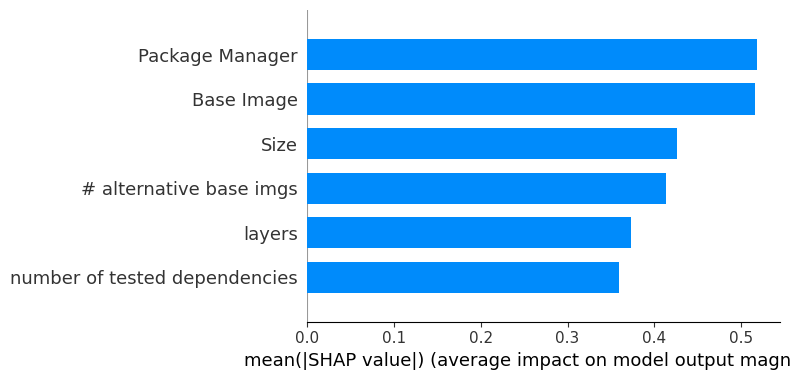

In [12]:
# Summary plot (bar) to see which features contribute most to anomalies
shap.summary_plot(shap_values, X, plot_type="bar")

In [13]:
# Pick first anomaly
anomaly_row = X[df['anomaly'] == -1].iloc[0]

# Force plot for that row
shap.force_plot(explainer.expected_value, shap_values[0], anomaly_row)


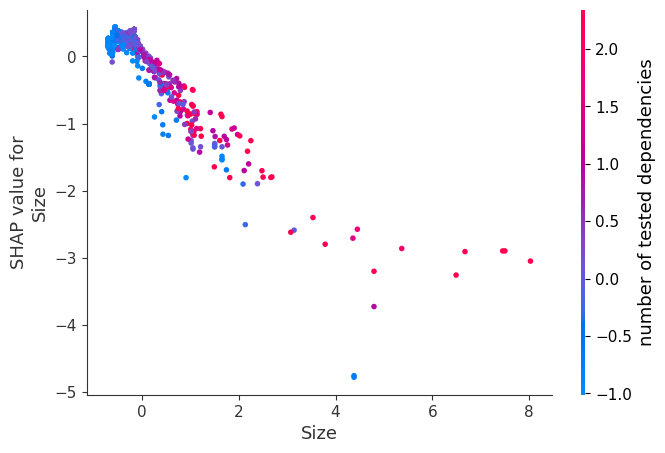

In [14]:
# See how a single feature affects anomaly scores across all images
shap.dependence_plot("Size", shap_values, X)

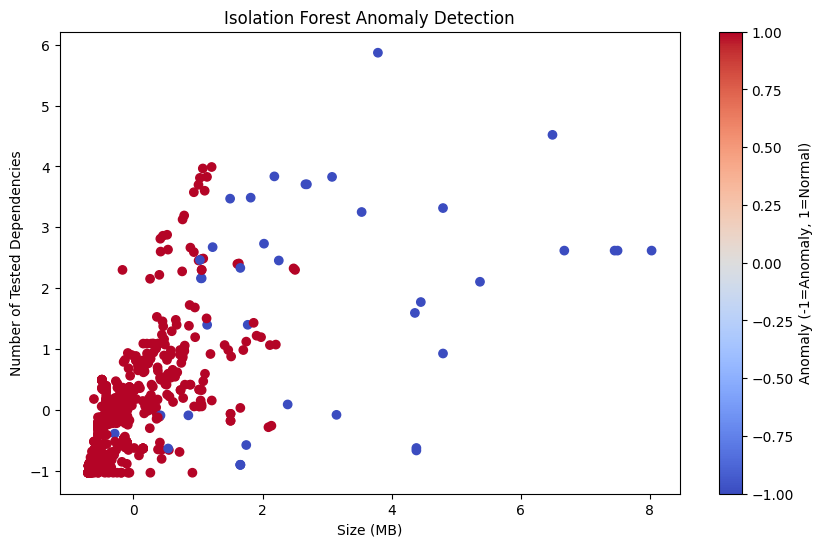

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df['Size'], df['number of tested dependencies'], 
            c=df['anomaly'], cmap='coolwarm', label='Anomaly')
plt.xlabel('Size (MB)')
plt.ylabel('Number of Tested Dependencies')
plt.title('Isolation Forest Anomaly Detection')
plt.colorbar(label='Anomaly (-1=Anomaly, 1=Normal)')
plt.show()

In [16]:
def generate_human_readable_unsupervised_text(
    row,
    anomaly_label,
    shap_row,
    feature_names,
    top_k=5
):
    shap_df = pd.DataFrame({
        "feature": feature_names,
        "value": row.values,
        "shap_value": shap_row
    })

    shap_df["abs_shap"] = shap_df["shap_value"].abs()
    shap_df = shap_df.sort_values("abs_shap", ascending=False)

    anomaly_reasons = []
    normal_reasons = []

    for _, r in shap_df.head(top_k).iterrows():
        feature = r["feature"]
        value = r["value"]
        shap_val = r["shap_value"]

        if shap_val < 0:
            anomaly_reasons.append(
                f"{feature} = {value} strongly contributed to this image being ANOMALOUS"
            )
        else:
            normal_reasons.append(
                f"{feature} = {value} reduced the anomaly risk"
            )

    output_text = f"""
Docker Image Anomaly Analysis

Final Model Decision:
This Docker image is classified as: {anomaly_label.upper()}

Primary reasons for anomaly detection:
- """ + "\n- ".join(anomaly_reasons[:3]) + f"""

Additional observations:
- """ + "\n- ".join(normal_reasons[:2]) + f"""

Interpretation:
This Docker image was flagged as anomalous because some features significantly
deviate from the normal Docker image patterns learned by the model.
"""

    return output_text.strip()

In [17]:
human_readable_outputs = []

anomaly_indices = df[df['anomaly'] == -1].index

for idx in anomaly_indices:
    row = X.loc[idx]
    shap_row = shap_values[idx]
    label = df.loc[idx, 'anomaly_label']

    text = generate_human_readable_unsupervised_text(
        row=row,
        anomaly_label=label,
        shap_row=shap_row,
        feature_names=X.columns
    )

    human_readable_outputs.append({
        "index": idx,
        "explanation": text
    })


In [18]:
df_explanations = pd.DataFrame(human_readable_outputs)
df_explanations.to_csv(
    "../data/preprocessed/unsupervised_human_readable_output.csv",
    index=False
)

print(" Human-readable unsupervised SHAP explanations saved!")

 Human-readable unsupervised SHAP explanations saved!


In [19]:
df.to_csv("../data/preprocessed/isolation_forest_results.csv", index=False)

In [20]:
joblib.dump(iso_forest, "../src/model_store/isolation_forest.pkl")

['../src/model_store/isolation_forest.pkl']

In [21]:
# Count how many anomalies
num_anomalies = (df['anomaly_label'] == 'Anomaly').sum()
print("Number of anomalous Docker images:", num_anomalies)

Number of anomalous Docker images: 39
